<a href="https://colab.research.google.com/github/DanendraPassadhi/PCVK/blob/main/PCVK_Week05_07.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# D-1 PERCOBAAN HISTOGRAM

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import cv2 as cv
from google.colab.patches import cv2_imshow
from skimage import io
import matplotlib.pyplot as plt
import numpy as np
import math
import os
import glob

<BarContainer object of 256 artists>

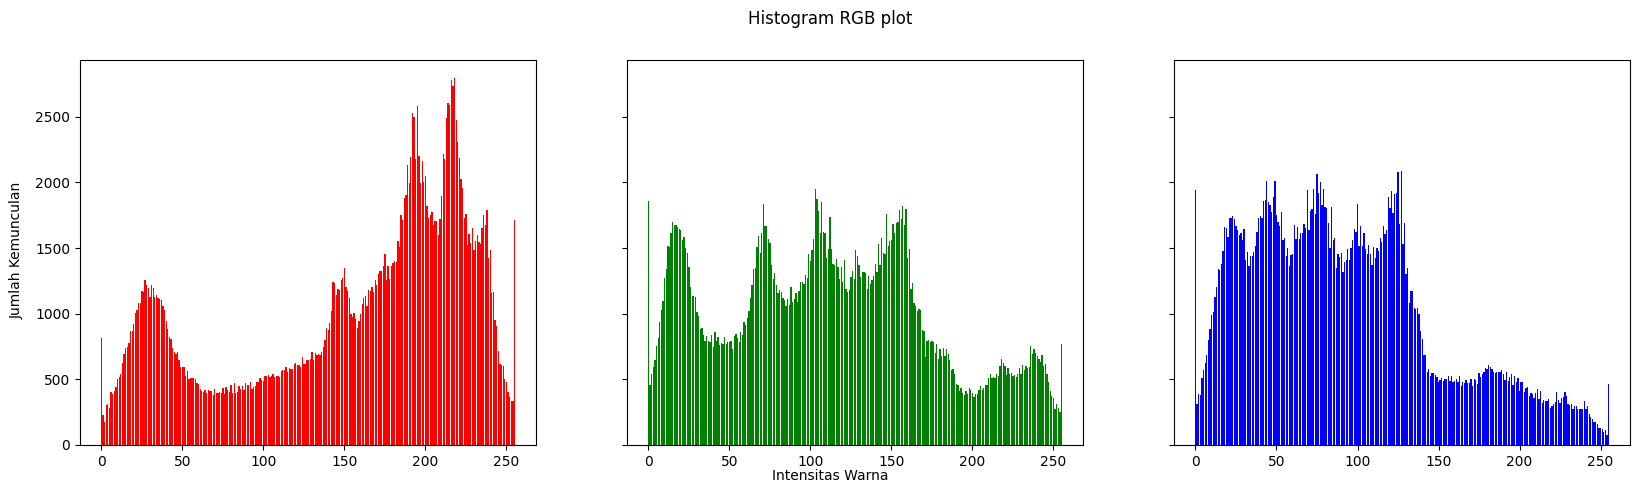

In [ ]:
#membuat histogram image (manual)
img = cv.imread('/content/drive/MyDrive/PCVK/lena.jpg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

height, width, depth = np.shape(img)
names = np.arange(256)

red = [0]*256
green = [0]*256
blue = [0]*256

for y in range(0,height) :
  for x in range(0,width) :
    red[img[y][x][0]] += 1
    green[img[y][x][1]] += 1
    blue[img[y][x][2]] += 1

names = np.arange(256)
fig, axs = plt.subplots(1, 3, figsize=[20,5], sharex=True, sharey=True)
fig.suptitle('Histogram RGB plot')
fig.text(0.09, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
fig.text(0.5, 0.04, 'Intensitas Warna', ha='center')
axs[0].bar(names, red, color='red')
axs[1].bar(names, green, color='green')
axs[2].bar(names, blue, color='blue')

## PERTANYAAN PRAKTIKUM D1

### 1. Buatlah histogram citra yang sama akan tetapi menggunakan library yang dimiliki oleh NumPy yaitu “histogram”. Bandingkan hasilnya. Apakah output muncul sama?

<BarContainer object of 256 artists>

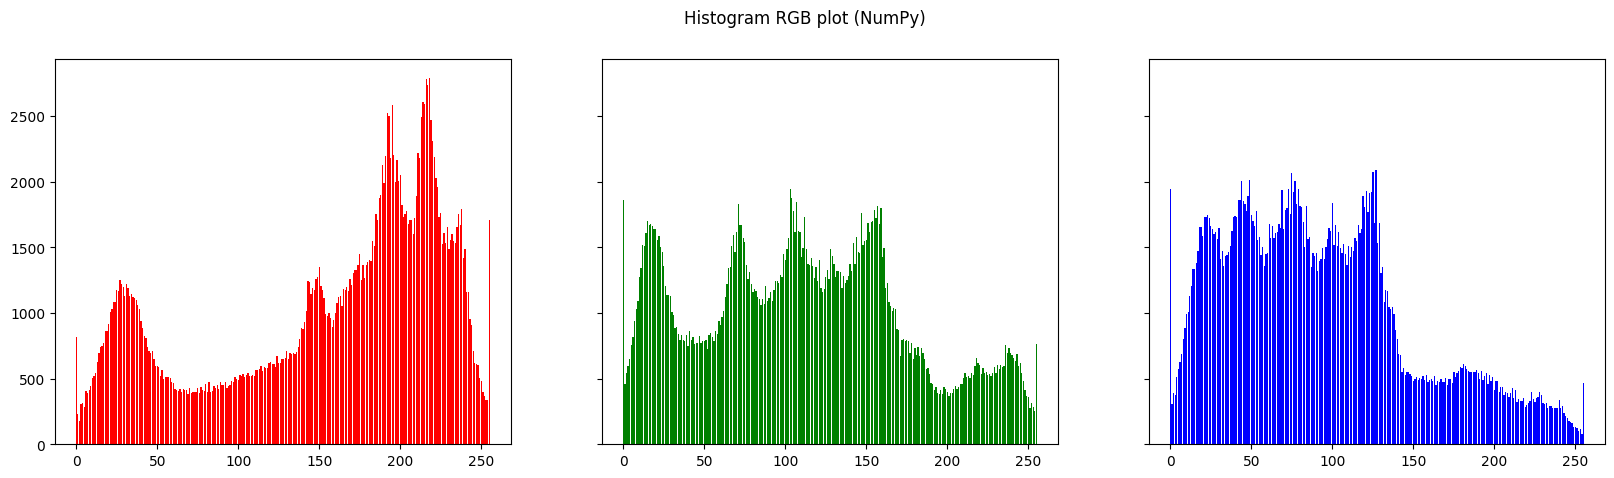

In [ ]:
red_hist, _ = np.histogram(img[:,:,0].flatten(), bins=256, range=[0,256])
green_hist, _ = np.histogram(img[:,:,1].flatten(), bins=256, range=[0,256])
blue_hist, _ = np.histogram(img[:,:,2].flatten(), bins=256, range=[0,256])

fig, axs = plt.subplots(1, 3, figsize=[20,5], sharex=True, sharey=True)
fig.suptitle('Histogram RGB plot (NumPy)')
axs[0].bar(names, red_hist, color='red')
axs[1].bar(names, green_hist, color='green')
axs[2].bar(names, blue_hist, color='blue')

↳ Output yang dikeluarkan sama.

### 2. Buatlah histogram dengan menggunakan dengan menggunakan image KTM lama.jpg. Analisis distribusi intensitas dari histogram yang dihasilkan apakah gambar cenderung gelap, terang, atau kontras rendah.

<BarContainer object of 256 artists>

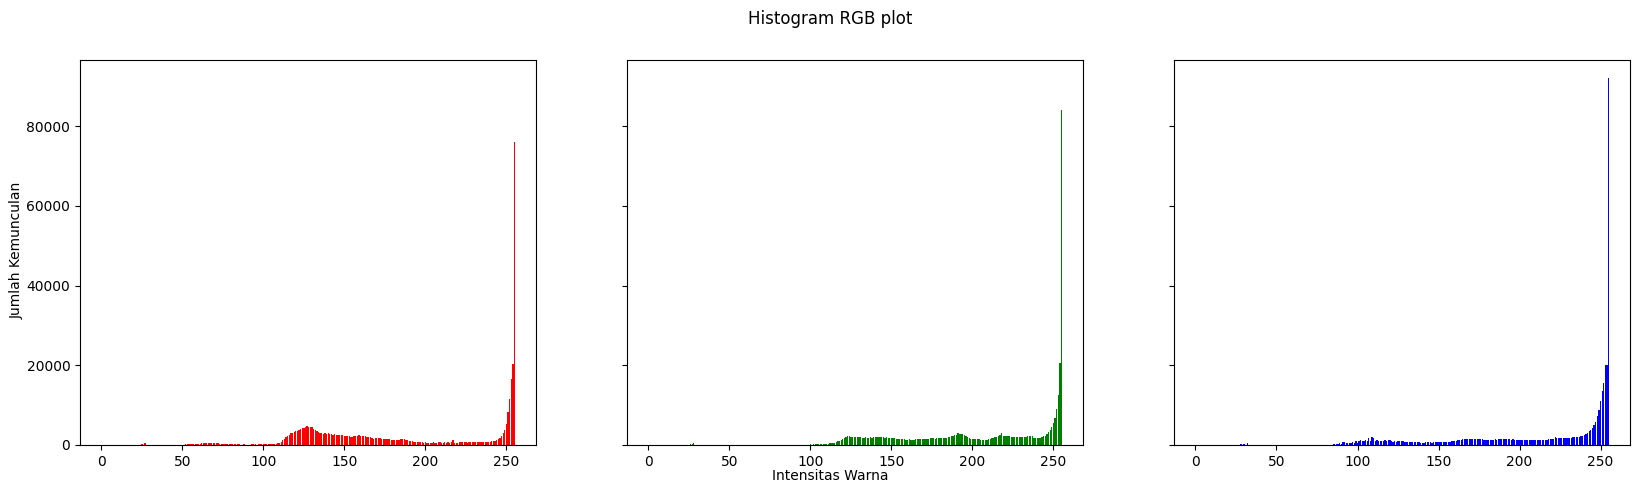

In [ ]:
#membuat histogram image (manual)
img = cv.imread('/content/drive/MyDrive/PCVK/KTM_lama.jpg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

height, width, depth = np.shape(img)
names = np.arange(256)

red = [0]*256
green = [0]*256
blue = [0]*256

for y in range(0,height) :
  for x in range(0,width) :
    red[img[y][x][0]] += 1
    green[img[y][x][1]] += 1
    blue[img[y][x][2]] += 1

names = np.arange(256)
fig, axs = plt.subplots(1, 3, figsize=[20,5], sharex=True, sharey=True)
fig.suptitle('Histogram RGB plot')
fig.text(0.09, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
fig.text(0.5, 0.04, 'Intensitas Warna', ha='center')
axs[0].bar(names, red, color='red')
axs[1].bar(names, green, color='green')
axs[2].bar(names, blue, color='blue')

↳ Citra KTM memiliki latar belakang dominan terang (putih/cerah), ditunjukkan oleh puncak tinggi pada intensitas 255 di semua kanal (R, G, B). Namun, ada beberapa bagian yang menunjukkan intensitas menengah.

# D-2 PERCOBAAN HISTOGRAM EQUALIZATION

## 1. Histogram Equalization

/tmp/ipython-input-3089836152.py:57: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(r.flatten(), 256, [0,256], color='red')
/tmp/ipython-input-3089836152.py:59: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(g.flatten(), 256, [0,256], color='green')
/tmp/ipython-input-3089836152.py:61: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(b.flatten(), 256, [0,256], color='blue')
/tmp/ipython-input-3089836152.py:64: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(r_eq.flatten(), 256, [0,2

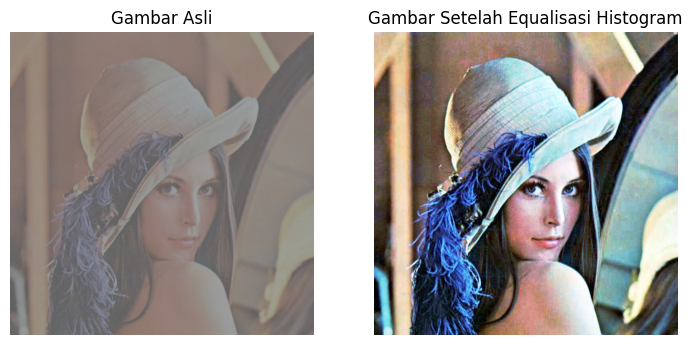

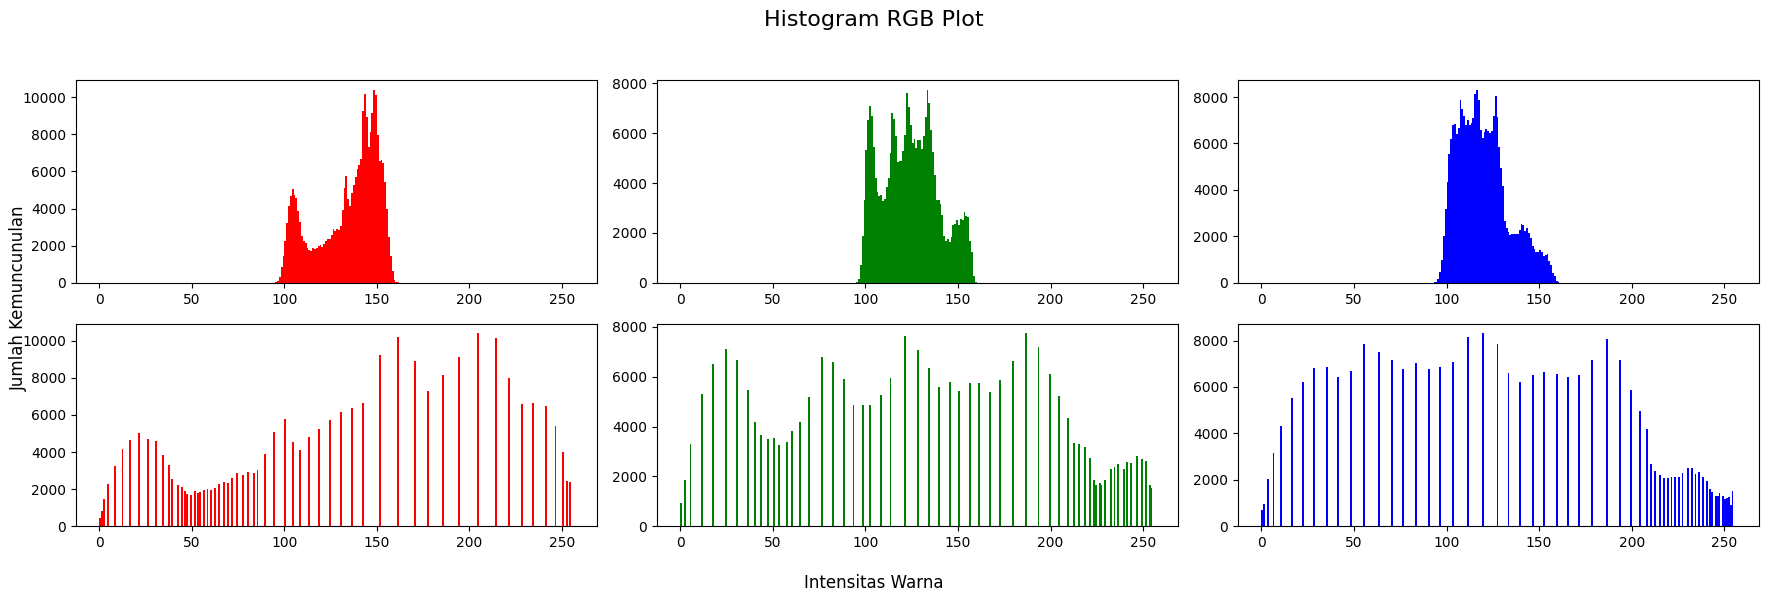

In [ ]:
img2 = cv.imread('/content/drive/MyDrive/PCVK/lena_lc.jpg')
img2_gray = cv.cvtColor(img2, cv.COLOR_BGR2GRAY)

img_bgr = img2
img_rgb = cv.cvtColor(img_bgr, cv.COLOR_BGR2RGB)

b, g, r = cv.split(img_bgr)

def manual_equalize_hist(channel):
    hist, bins = np.histogram(channel.flatten(), 256, [0, 256])
    cdf = hist.cumsum()

    cdf_normalized = cdf * hist.max() / cdf.max()

    cdf_m = np.ma.masked_equal(cdf, 0)
    cdf_m = (cdf_m - cdf_m.min()) * 255 / (cdf_m.max() - cdf_m.min())
    cdf = np.ma.filled(cdf_m, 0).astype('uint8')

    img_eq = cdf[channel]
    return img_eq

r_eq = manual_equalize_hist(r)
g_eq = manual_equalize_hist(g)
b_eq = manual_equalize_hist(b)

img_eq_bgr = cv.merge((b_eq, g_eq, r_eq))
img_eq_rgb = cv.cvtColor(img_eq_bgr, cv.COLOR_BGR2RGB)

# Gambar
plt.figure(figsize=(18, 12))

plt.subplot(2, 4, 1)
plt.imshow(img_rgb)
plt.title('Gambar Asli')
plt.axis('off')

plt.subplot(2, 4, 2)
plt.imshow(img_eq_rgb)
plt.title('Gambar Setelah Equalisasi Histogram')
plt.axis('off')

# Plot histogram
fig = plt.figure(figsize=(18,6))
fig.suptitle('Histogram RGB Plot', fontsize=16)

plt.subplot(2, 3, 1)
plt.hist(r.flatten(), 256, [0,256], color='red')
plt.subplot(2, 3, 2)
plt.hist(g.flatten(), 256, [0,256], color='green')
plt.subplot(2, 3, 3)
plt.hist(b.flatten(), 256, [0,256], color='blue')

plt.subplot(2, 3, 4)
plt.hist(r_eq.flatten(), 256, [0,256], color='red')
plt.subplot(2, 3, 5)
plt.hist(g_eq.flatten(), 256, [0,256], color='green')
plt.subplot(2, 3, 6)
plt.hist(b_eq.flatten(), 256, [0,256], color='blue')

fig.supxlabel("Intensitas Warna", fontsize=12)
fig.supylabel("Jumlah Kemuncunulan", fontsize=12)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

## 2. Histogram Equalization dengan CV2 yaitu “equalizeHist”

/tmp/ipython-input-97429618.py:33: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(r.flatten(), 256, [0,256], color='red')
/tmp/ipython-input-97429618.py:35: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(g.flatten(), 256, [0,256], color='green')
/tmp/ipython-input-97429618.py:37: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(b.flatten(), 256, [0,256], color='blue')
/tmp/ipython-input-97429618.py:40: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(r_eq.flatten(), 256, [0,256], col

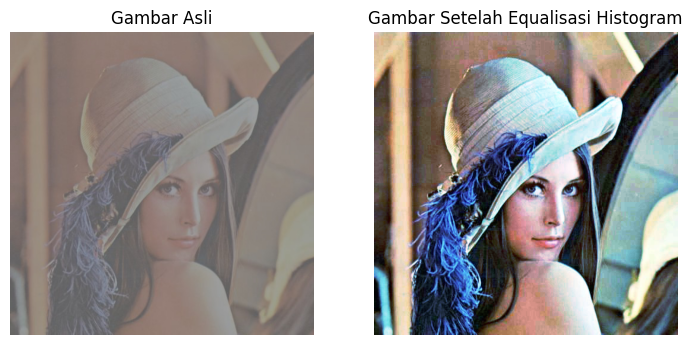

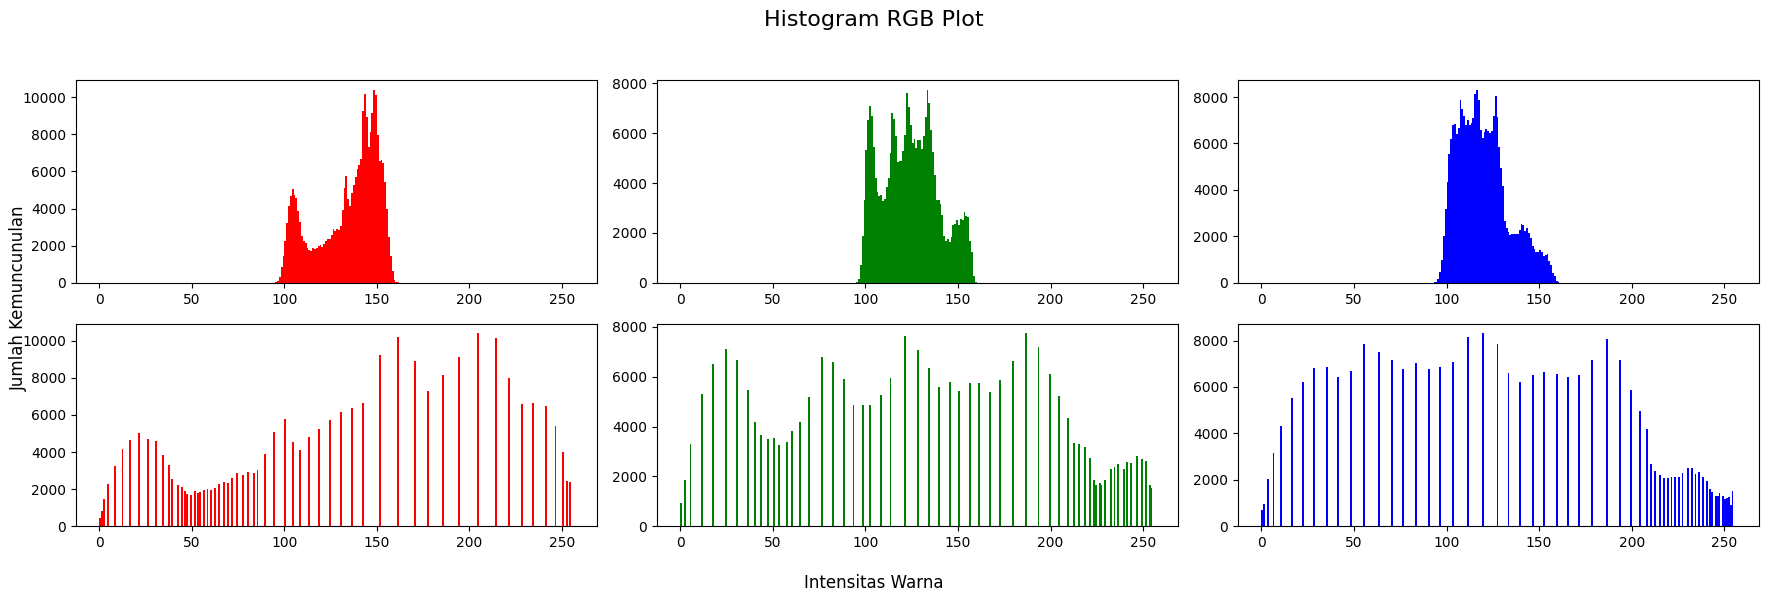

In [6]:
img2 = cv.imread('/content/drive/MyDrive/PCVK/lena_lc.jpg')
img2_gray = cv.cvtColor(img2, cv.COLOR_BGR2GRAY)

img_bgr = img2
img_rgb = cv.cvtColor(img_bgr, cv.COLOR_BGR2RGB)

b, g, r = cv.split(img_bgr)
b_equalized = cv.equalizeHist(b)
g_equalized = cv.equalizeHist(g)
r_equalized = cv.equalizeHist(r)

img_eq_bgr = cv.merge((b_equalized, g_equalized, r_equalized))
img_eq_rgb = cv.cvtColor(img_eq_bgr, cv.COLOR_BGR2RGB)

# Gambar
plt.figure(figsize=(18, 12))

plt.subplot(2, 4, 1)
plt.imshow(img_rgb)
plt.title('Gambar Asli')
plt.axis('off')

plt.subplot(2, 4, 2)
plt.imshow(img_eq_rgb)
plt.title('Gambar Setelah Equalisasi Histogram')
plt.axis('off')

# Plot histogram
fig = plt.figure(figsize=(18,6))
fig.suptitle('Histogram RGB Plot', fontsize=16)

plt.subplot(2, 3, 1)
plt.hist(r.flatten(), 256, [0,256], color='red')
plt.subplot(2, 3, 2)
plt.hist(g.flatten(), 256, [0,256], color='green')
plt.subplot(2, 3, 3)
plt.hist(b.flatten(), 256, [0,256], color='blue')

plt.subplot(2, 3, 4)
plt.hist(r_eq.flatten(), 256, [0,256], color='red')
plt.subplot(2, 3, 5)
plt.hist(g_eq.flatten(), 256, [0,256], color='green')
plt.subplot(2, 3, 6)
plt.hist(b_eq.flatten(), 256, [0,256], color='blue')

fig.supxlabel("Intensitas Warna", fontsize=12)
fig.supylabel("Jumlah Kemuncunulan", fontsize=12)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

## PERTANYAAN PRAKTIKUM D2

### 1. Perbandingan Citra Lena

#### a. Gunakan hasil histogram equalization pada citra lena.jpg.

/tmp/ipython-input-818313022.py:47: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(r.flatten(), 256, [0,256], color='red')
/tmp/ipython-input-818313022.py:49: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(g.flatten(), 256, [0,256], color='green')
/tmp/ipython-input-818313022.py:51: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(b.flatten(), 256, [0,256], color='blue')
/tmp/ipython-input-818313022.py:54: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(r_eq.flatten(), 256, [0,256],

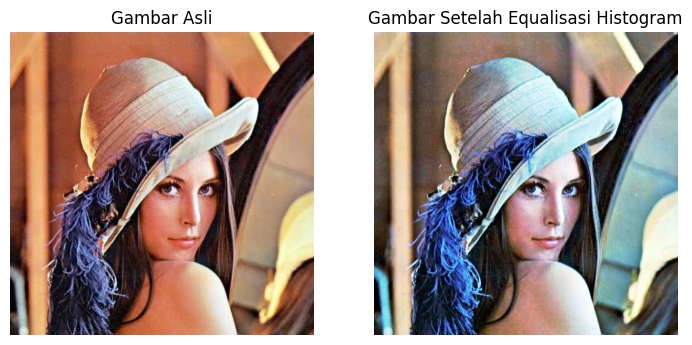

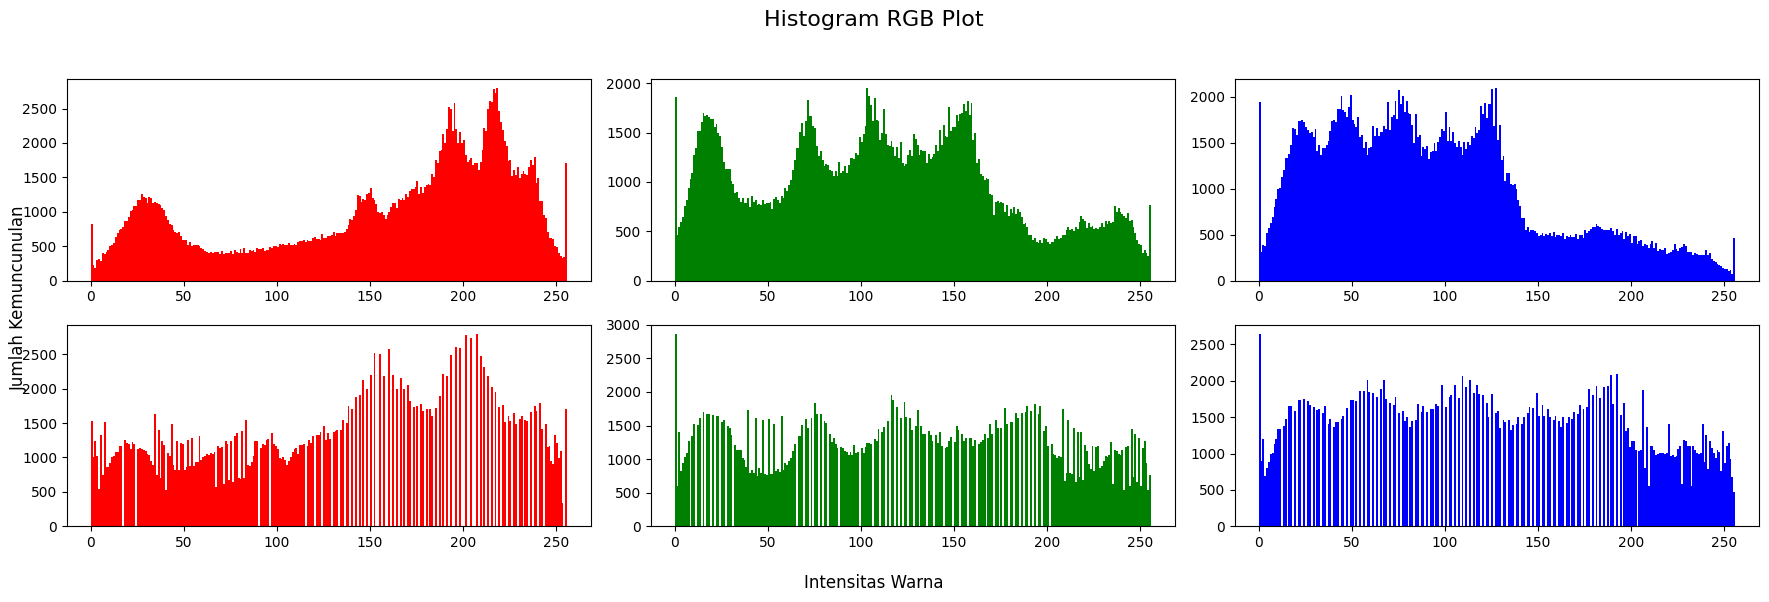

In [7]:
img2 = cv.imread('/content/drive/MyDrive/PCVK/lena.jpg')
img2_gray = cv.cvtColor(img2, cv.COLOR_BGR2GRAY)

img_bgr = img2
img_rgb = cv.cvtColor(img_bgr, cv.COLOR_BGR2RGB)

b, g, r = cv.split(img_bgr)

def manual_equalize_hist(channel):
    hist, bins = np.histogram(channel.flatten(), 256, [0, 256])
    cdf = hist.cumsum()

    cdf_normalized = cdf * hist.max() / cdf.max()

    cdf_m = np.ma.masked_equal(cdf, 0)
    cdf_m = (cdf_m - cdf_m.min()) * 255 / (cdf_m.max() - cdf_m.min())
    cdf = np.ma.filled(cdf_m, 0).astype('uint8')

    img_eq = cdf[channel]
    return img_eq

r_eq = manual_equalize_hist(r)
g_eq = manual_equalize_hist(g)
b_eq = manual_equalize_hist(b)

img_eq_bgr = cv.merge((b_eq, g_eq, r_eq))
img_eq_rgb = cv.cvtColor(img_eq_bgr, cv.COLOR_BGR2RGB)

# Gambar
plt.figure(figsize=(18, 12))

plt.subplot(2, 4, 1)
plt.imshow(img_rgb)
plt.title('Gambar Asli')
plt.axis('off')

plt.subplot(2, 4, 2)
plt.imshow(img_eq_rgb)
plt.title('Gambar Setelah Equalisasi Histogram')
plt.axis('off')

# Plot histogram
fig = plt.figure(figsize=(18,6))
fig.suptitle('Histogram RGB Plot', fontsize=16)

plt.subplot(2, 3, 1)
plt.hist(r.flatten(), 256, [0,256], color='red')
plt.subplot(2, 3, 2)
plt.hist(g.flatten(), 256, [0,256], color='green')
plt.subplot(2, 3, 3)
plt.hist(b.flatten(), 256, [0,256], color='blue')

plt.subplot(2, 3, 4)
plt.hist(r_eq.flatten(), 256, [0,256], color='red')
plt.subplot(2, 3, 5)
plt.hist(g_eq.flatten(), 256, [0,256], color='green')
plt.subplot(2, 3, 6)
plt.hist(b_eq.flatten(), 256, [0,256], color='blue')

fig.supxlabel("Intensitas Warna", fontsize=12)
fig.supylabel("Jumlah Kemuncunulan", fontsize=12)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

#### b. Hitung nilai PSNR antara citra asli dan citra hasil equalization.

In [8]:
# Hitung Mean Squared Error (MSE)
mse = np.mean((img_rgb - img_eq_rgb) ** 2)

# Jika MSE adalah 0, PSNR tidak terdefinisi
if mse == 0:
    psnr = float('inf')
else:
    # Hitung PSNR
    max_pixel = 255.0
    psnr = 20 * np.log10(max_pixel / np.sqrt(mse))

print(f"Nilai PSNR antara citra asli dan citra hasil equalisasi: {psnr:.2f} dB")

Nilai PSNR antara citra asli dan citra hasil equalisasi: 28.33 dB


#### c. Apakah nilai PSNR tinggi atau rendah? Apa arti nilai tersebut terhadap kualitas visual citra? Apakah ada detail baru yang muncul setelah equalization?

↳ Nilai PSNR cukup baik, tapi masih ada sedikit perbedaan yang bisa terlihat dibanding citra aslinya.

### 2. Gunakan Citra KTM Lama.jpg

#### a. Terapkan histogram equalization pada citra KTM lama.jpg. <br> b. Tampilkan citra asli, citra hasil equalization, serta histogram keduanya dalam satu layout.

/tmp/ipython-input-3220737033.py:47: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(r.flatten(), 256, [0,256], color='red')
/tmp/ipython-input-3220737033.py:49: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(g.flatten(), 256, [0,256], color='green')
/tmp/ipython-input-3220737033.py:51: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(b.flatten(), 256, [0,256], color='blue')
/tmp/ipython-input-3220737033.py:54: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(r_eq.flatten(), 256, [0,2

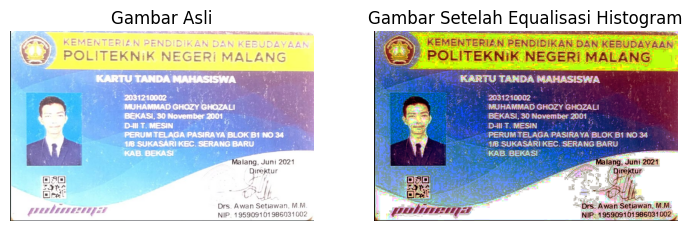

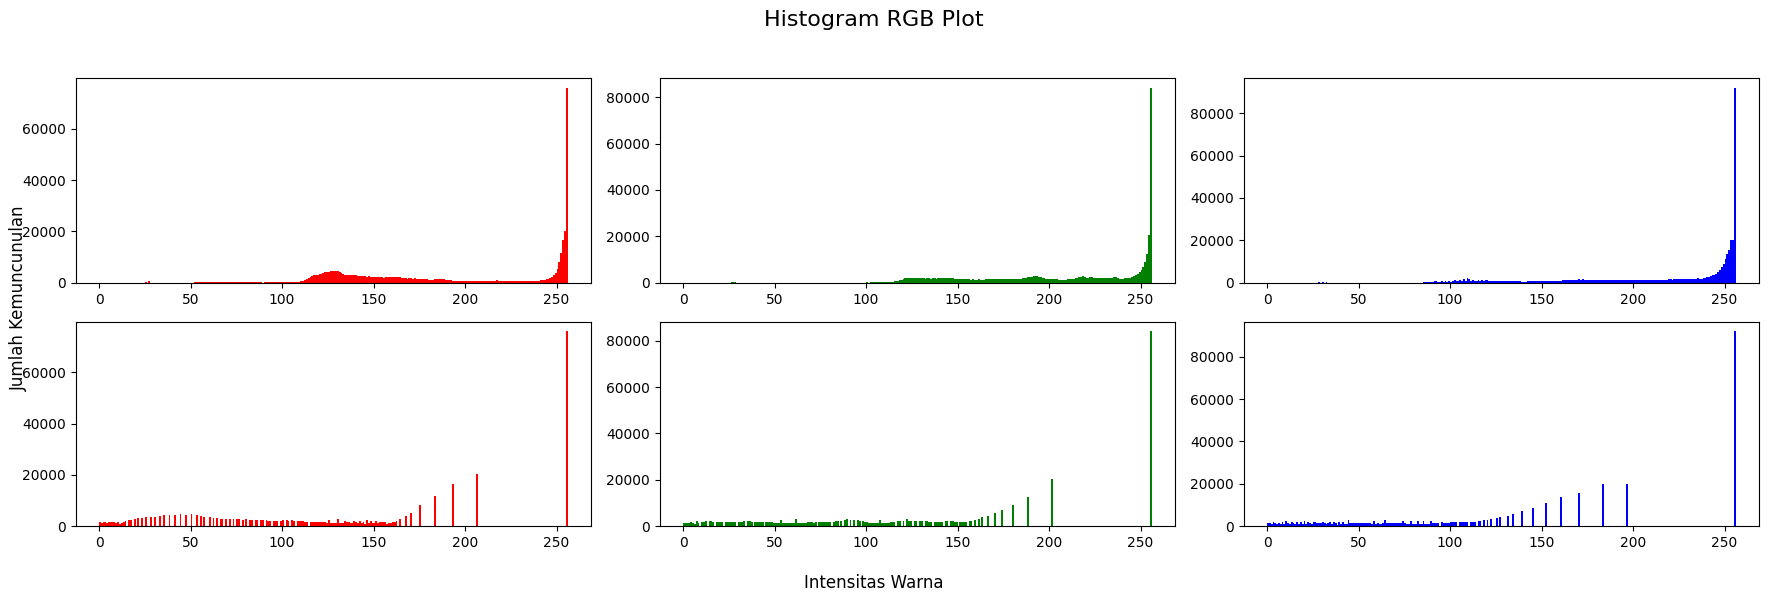

In [9]:
img2 = cv.imread('/content/drive/MyDrive/PCVK/KTM_lama.jpg')

img_rgb = cv.cvtColor(img2, cv.COLOR_BGR2RGB)

b, g, r = cv.split(img_bgr)

def manual_equalize_hist(channel):
    hist, bins = np.histogram(channel.flatten(), 256, [0, 256])
    cdf = hist.cumsum()

    cdf_normalized = cdf * hist.max() / cdf.max()

    cdf_m = np.ma.masked_equal(cdf, 0)
    cdf_m = (cdf_m - cdf_m.min()) * 255 / (cdf_m.max() - cdf_m.min())
    cdf = np.ma.filled(cdf_m, 0).astype('uint8')

    img_eq = cdf[channel]
    return img_eq

r_eq = manual_equalize_hist(r)
g_eq = manual_equalize_hist(g)
b_eq = manual_equalize_hist(b)

img_eq_bgr = cv.merge((b_eq, g_eq, r_eq))
img_eq_rgb = cv.cvtColor(img_eq_bgr, cv.COLOR_BGR2RGB)

# Gambar
plt.figure(figsize=(18, 12))

plt.subplot(2, 4, 1)
plt.imshow(img_rgb)
plt.title('Gambar Asli')
plt.axis('off')

plt.subplot(2, 4, 2)
plt.imshow(img_eq_rgb)
plt.title('Gambar Setelah Equalisasi Histogram')
plt.axis('off')

# Plot histogram
fig = plt.figure(figsize=(18,6))
fig.suptitle('Histogram RGB Plot', fontsize=16)

plt.subplot(2, 3, 1)
plt.hist(r.flatten(), 256, [0,256], color='red')
plt.subplot(2, 3, 2)
plt.hist(g.flatten(), 256, [0,256], color='green')
plt.subplot(2, 3, 3)
plt.hist(b.flatten(), 256, [0,256], color='blue')

plt.subplot(2, 3, 4)
plt.hist(r_eq.flatten(), 256, [0,256], color='red')
plt.subplot(2, 3, 5)
plt.hist(g_eq.flatten(), 256, [0,256], color='green')
plt.subplot(2, 3, 6)
plt.hist(b_eq.flatten(), 256, [0,256], color='blue')

fig.supxlabel("Intensitas Warna", fontsize=12)
fig.supylabel("Jumlah Kemuncunulan", fontsize=12)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

**Perbedaan**
- **Detail Wajah** <br>
**Sebelum**: Wajah terlihat agak redup, warna kulit sedikit pudar, dan bayangan lebih menutupi detail. <br>
**Sesudah**: Wajah menjadi lebih jelas, detail garis wajah dan rambut lebih menonjol. Namun, efeknya kadang membuat warna kulit jadi terlalu kontras sehingga tampak agak “keras” atau tidak natural.

- **Teks** <br>
**Sebelum**: Tulisan (nama, NIM, jurusan, dsb.) masih terbaca, tapi ada bagian teks yang sedikit buram karena pencahayaan atau dominasi warna latar. <br>
**Sesudah**: Teks menjadi lebih tajam dan lebih mudah dibedakan dari latar belakang. Kontras tinggi membantu meningkatkan keterbacaan, meskipun kadang bisa muncul efek bintik (noise) di sekitar huruf.

- **Latar Belakang** <br>
**Sebelum**: Warna latar belakang terlihat lebih natural tetapi agak kusam. <br>
**Sesudah**: Latar belakang menjadi jauh lebih terang/gelap sesuai distribusi histogram. Gradasi warna lebih ekstrem, sehingga detail pola latar belakang lebih muncul, tapi bisa membuat gambar terlihat kasar.

- **Kualitas Informasi** <br>
**Peningkatan**: Secara fungsional, histogram equalization membantu meningkatkan keterbacaan teks dan memperjelas detail wajah, sehingga informasi lebih mudah diakses. <br>
**Kelemahan**: Visual keseluruhan jadi lebih “keras” (over-contrast), warna asli kartu bisa tampak berubah dari aslinya, dan bisa menurunkan estetika naturalitas citra.

# D-3 TUGAS PRAKTIKUM DITHERING

## 1. Melakukan proses dithering Floyd and Steinberg

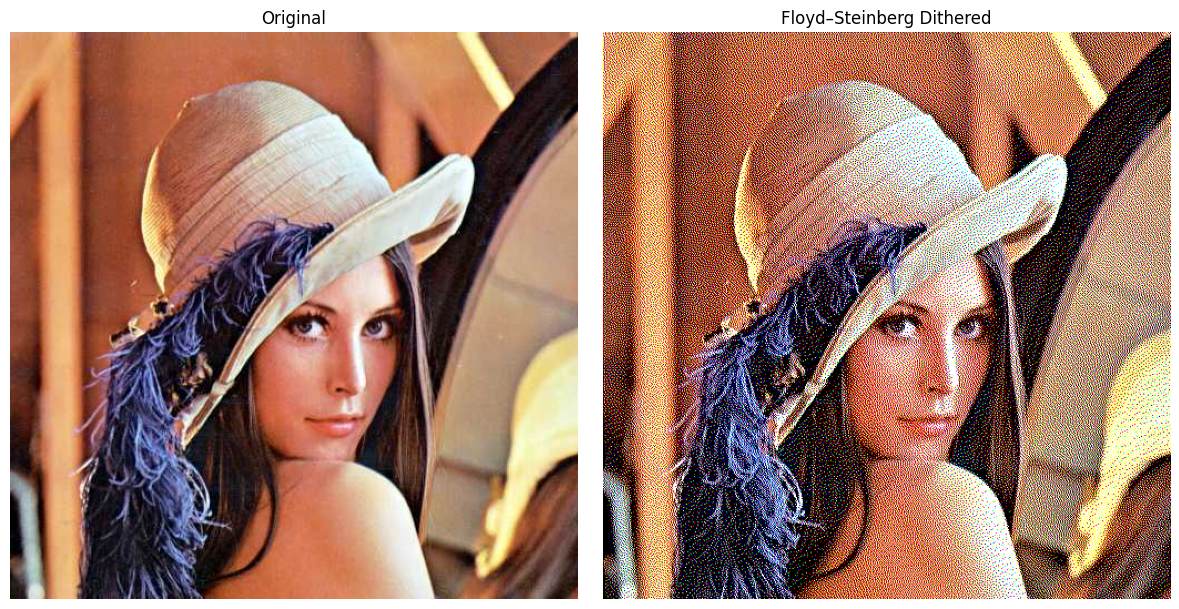

In [16]:
img3 = cv.imread('/content/drive/MyDrive/PCVK/lena.jpg')

img_float = img3.astype(np.float32)
h, w, ch = img_float.shape

for y in range(h):
    for x in range(w):
        for c in range(ch):
            old = img_float[y, x, c]
            new = 255.0 if old > 127.5 else 0.0
            img_float[y, x, c] = new
            err = old - new
            if x + 1 < w:
                img_float[y, x + 1, c] += err * 7.0 / 16.0
            if y + 1 < h:
                if x - 1 >= 0:
                    img_float[y + 1, x - 1, c] += err * 3.0 / 16.0
                img_float[y + 1, x, c] += err * 5.0 / 16.0
                if x + 1 < w:
                    img_float[y + 1, x + 1, c] += err * 1.0 / 16.0

dithered = np.clip(img_float, 0, 255).astype(np.uint8)

img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)
dithered_rgb = cv.cvtColor(dithered, cv.COLOR_BGR2RGB)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(img_rgb)
axes[0].set_title('Original')
axes[0].axis('off')

axes[1].imshow(dithered_rgb)
axes[1].set_title('Floyd–Steinberg Dithered')
axes[1].axis('off')

plt.tight_layout()
plt.show()


## 2. Menggunakan lena_lc.jpg rubah menjadi grey image, kemudian terapkan histogram equalization

Grayscale dtype: uint8 min: 16 max: 255


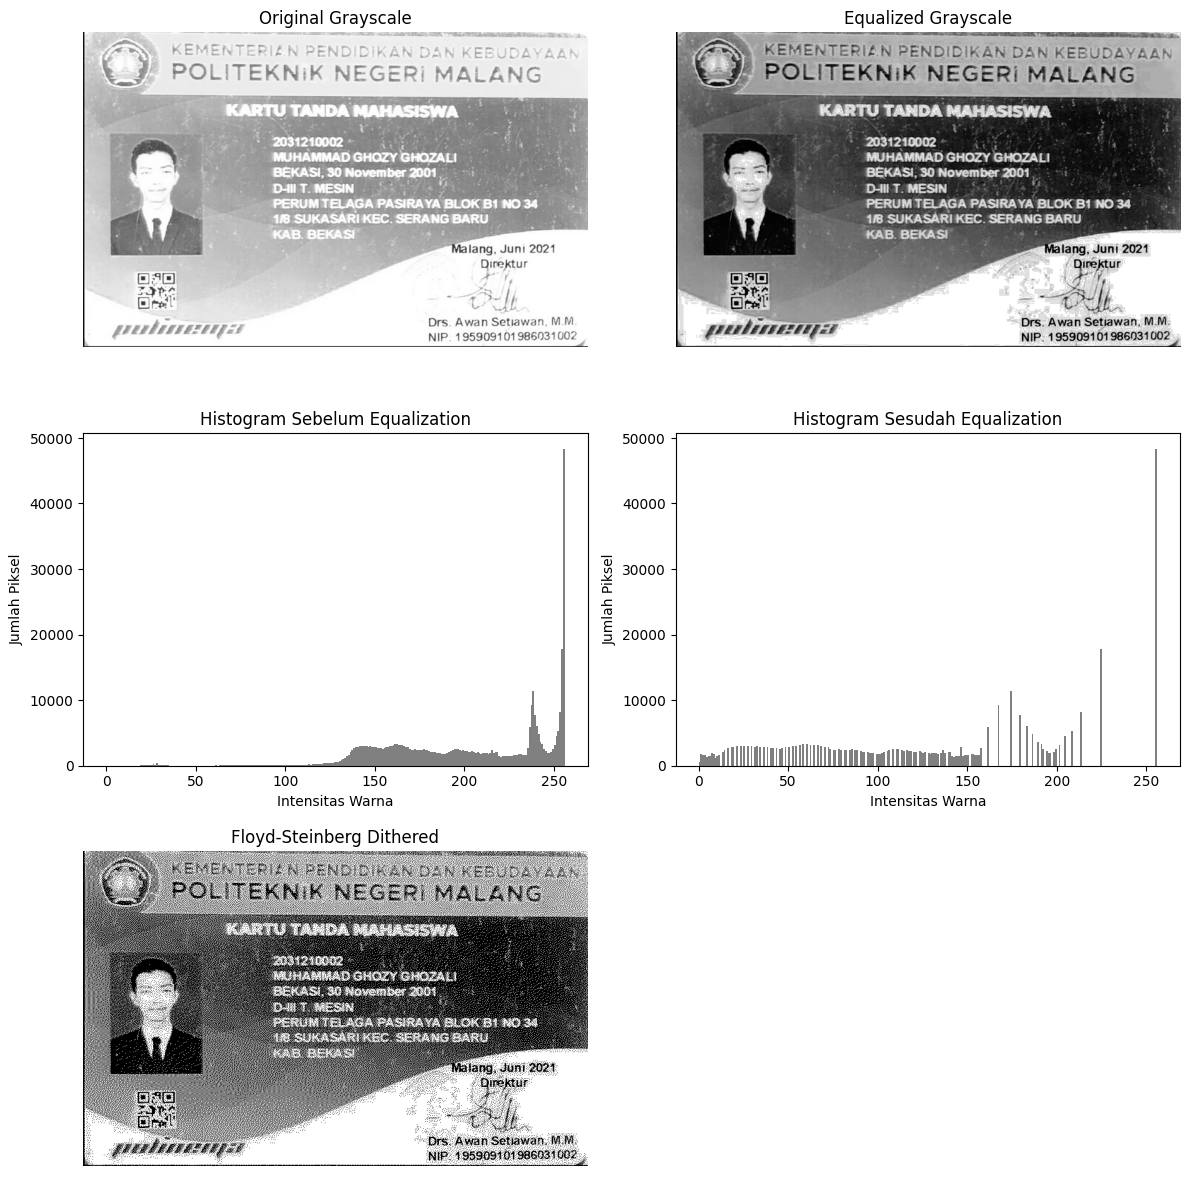

In [13]:
imgLena = cv.imread('/content/drive/MyDrive/PCVK/KTM_lama.jpg')

gray = cv.cvtColor(imgLena, cv.COLOR_BGR2GRAY)
print("Grayscale dtype:", gray.dtype, "min:", gray.min(), "max:", gray.max())

equalized = cv.equalizeHist(gray)

def floyd_steinberg_dither(image):
    img_float = image.astype(np.float32)
    h, w = img_float.shape
    for y in range(h):
        for x in range(w):
            old_pixel = img_float[y, x]
            new_pixel = 255.0 if old_pixel > 127.5 else 0.0
            img_float[y, x] = new_pixel
            error = old_pixel - new_pixel

            if x + 1 < w:
                img_float[y, x + 1] += error * 7.0 / 16.0
            if y + 1 < h:
                if x - 1 >= 0:
                    img_float[y + 1, x - 1] += error * 3.0 / 16.0
                img_float[y + 1, x] += error * 5.0 / 16.0
                if x + 1 < w:
                    img_float[y + 1, x + 1] += error * 1.0 / 16.0

            img_float = np.clip(img_float, 0, 255)
    return img_float.astype(np.uint8)

dithered = floyd_steinberg_dither(equalized)

fig, axs = plt.subplots(3, 2, figsize=(12, 12))
axs[0, 0].imshow(gray, cmap='gray')
axs[0, 0].set_title("Original Grayscale")
axs[0, 0].axis('off')

axs[0, 1].imshow(equalized, cmap='gray')
axs[0, 1].set_title("Equalized Grayscale")
axs[0, 1].axis('off')

axs[1, 0].hist(gray.ravel(), bins=256, range=(0, 256), color='gray')
axs[1, 0].set_title("Histogram Sebelum Equalization")
axs[1, 0].set_xlabel("Intensitas Warna")
axs[1, 0].set_ylabel("Jumlah Piksel")

axs[1, 1].hist(equalized.ravel(), bins=256, range=(0, 256), color='gray')
axs[1, 1].set_title("Histogram Sesudah Equalization")
axs[1, 1].set_xlabel("Intensitas Warna")
axs[1, 1].set_ylabel("Jumlah Piksel")

axs[2, 0].imshow(dithered, cmap='gray')
axs[2, 0].set_title("Floyd-Steinberg Dithered")
axs[2, 0].axis('off')

axs[2, 1].axis('off')
plt.tight_layout()
plt.show()